# Aula 02 — Métodos Baseados em Valores
## Notebook 05 — Comparativo final e transição para a Aula 03

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Tema:** Comparação entre DP, MC, TD, Q-Learning, SARSA e DQN  
**Ambientes:** FrozenLake-v1, Taxi-v3

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 02 — Métodos Baseados em Valores |
| **Notebook** | 05 — Comparativo Final |
| **Seções** | 2.1–2.9 (síntese) |
| **Tempo de leitura** | 18 min |
| **Tempo de execução (padrão)** | 6 min |

### Pré-requisitos

- **Notebooks anteriores:** `01` a `04` — todos os métodos value-based devem ter sido estudados.
- **Conceitos:** DP, MC, TD, Q-Learning, SARSA, DQN.

### Competências para o Desafio Final

- Escolher o método value-based adequado a cada cenário (modelo disponível, espaço discreto, estado contínuo).
- Reproduzir a comparação Q-Learning vs SARSA e interpretar as diferenças.
- Articular por que ações contínuas exigem Policy-Based Methods (Aula 03).

### Recapitulando

Os notebooks 01–04 percorreram a progressão **DP → MC → TD → Q-Learning → SARSA → DQN**. Cada passo superou uma limitação anterior: necessidade de modelo, necessidade de tabela, necessidade de ações discretas. Este notebook consolida essa jornada em uma comparação única.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta

Ao longo desta aula, seis métodos foram apresentados, cada um respondendo à mesma pergunta central de uma forma diferente:

> **Como um agente aprende a atribuir valor a estados e ações para tomar melhores decisões?**

Este notebook tem três partes:

1. **Tabela comparativa** — todos os seis métodos em uma visão única, para consolidar a progressão da aula.
2. **Experimento final** — Q-Learning vs SARSA no FrozenLake, para ver a distinção on/off-policy em um ambiente diferente do Taxi-v3 (aqui, a estocasticidade do gelo, não as penalidades do Taxi, é o fator decisivo).
3. **Transição para a Aula 03** — onde os métodos value-based não chegam e o que a próxima aula responde.

**Mensagem principal:**
> *Cada método responde de forma diferente à mesma pergunta: qual ação vale mais?*

## Tabela comparativa dos métodos

| Método | Precisa de modelo? | Quando atualiza | Alvo de atualização | On/Off-policy | Espaço de estados |
|---|---|---|---|---|---|
| **Programação Dinâmica** | Sim | Sweeps (offline) | Bellman exato | — | Discreto, pequeno |
| **Monte Carlo** | Não | Fim do episódio | Retorno completo G_t | On-policy (aprende sobre a política executada) | Discreto |
| **TD(0)** | Não | A cada passo | r + γ·V(s') | On-policy | Discreto |
| **Q-Learning** | Não | A cada passo | r + γ·max Q(s',a') | Off-policy (aprende sobre a melhor política possível) | Discreto |
| **SARSA** | Não | A cada passo | r + γ·Q(s',a') | On-policy | Discreto |
| **DQN** | Não | A cada passo (minibatch) | r + γ·max Q_alvo(s',a') | Off-policy | Contínuo/grande |

**Progressão da aula:** modelo disponível → sem modelo (episódico) → sem modelo (incremental) → controle tabular → controle com rede neural

In [2]:
# Instalação opcional das dependências
# %pip install gymnasium numpy matplotlib

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Versões utilizadas:")
print("numpy:", np.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", plt.matplotlib.__version__)

Versões utilizadas:
numpy: 2.4.2
gymnasium: 1.0.0
matplotlib: 3.10.8


## Bloco 2 — Mini teoria: o que diferencia cada família de métodos

**Necessidade de modelo:**
- DP exige P(s'|s,a) e R(s,a,s') completos → impraticável em problemas reais
- MC, TD, Q-Learning, SARSA, DQN aprendem apenas de interações com o ambiente

**Momento da atualização:**
- MC: só após o fim do episódio → não funciona em episódios muito longos ou contínuos
- TD em diante: a cada passo → funciona em qualquer horizonte

**On-policy vs off-policy:**
- On-policy (MC, TD, SARSA): aprende sobre a política atual, incluindo custo da exploração
- Off-policy (Q-Learning, DQN): aprende sobre a política ótima independentemente do comportamento

**Tabular vs aproximação por função:**
- Tabular: funciona para espaços discretos pequenos
- Aproximação (DQN): necessária quando o estado é contínuo ou exponencialmente grande

## Bloco 3 — Comparação direta: Q-Learning vs SARSA

O Notebook 03 comparou Q-Learning e SARSA no **Taxi-v3**, onde a distinção on/off-policy aparece principalmente pelas penalidades de ações ilegais (−10 por tentativa de embarque/desembarque errado). Aqui a comparação é no **FrozenLake-v1 com gelo escorregadio** — um ambiente diferente, com um fator de risco diferente.

No FrozenLake, a estocasticidade do ambiente é o que revela a diferença: mesmo executando a ação "correta", o agente pode deslizar para uma direção indesejada. Isso torna o custo da exploração mais difuso e imprevisível do que as penalidades diretas do Taxi. Observar Q-Learning vs SARSA nesse contexto complementa — não repete — o que foi visto antes.

**Para uma análise mais rica com o Taxi-v3**, incluindo curvas de divergência, ver o Notebook 03.

In [4]:
env_fl = gym.make("FrozenLake-v1", is_slippery=True)

def epsilon_greedy(Q, estado, epsilon, n_acoes):
    if random.random() < epsilon:
        return random.randrange(n_acoes)
    return int(np.argmax(Q[estado]))

def treinar_qlearning(env, episodios=4000, alpha=0.1, gamma=0.99,
                      eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999):
    n_s = env.observation_space.n
    n_a = env.action_space.n
    Q = np.zeros((n_s, n_a), dtype=float)
    log = []
    eps = eps_inicio
    for ep in range(episodios):
        estado, _ = env.reset(seed=SEED + ep)
        done = False
        total = 0.0
        while not done:
            acao = epsilon_greedy(Q, estado, eps, n_a)
            prox, r, term, trunc, _ = env.step(acao)
            done = term or trunc
            # Off-policy: aprende sobre a ação ótima (max), não sobre a ação que será tomada
            alvo = r + gamma * np.max(Q[prox]) * (0 if done else 1)
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])
            estado = prox
            total += r
        log.append(total)
        eps = max(eps_fim, eps * eps_decaimento)
    return Q, np.array(log)

def treinar_sarsa(env, episodios=4000, alpha=0.1, gamma=0.99,
                  eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999):
    n_s = env.observation_space.n
    n_a = env.action_space.n
    Q = np.zeros((n_s, n_a), dtype=float)
    log = []
    eps = eps_inicio
    for ep in range(episodios):
        estado, _ = env.reset(seed=SEED + 10000 + ep)
        # SARSA: a' já escolhida antes do loop — on-policy inclui custo de exploração no alvo
        acao = epsilon_greedy(Q, estado, eps, n_a)
        done = False
        total = 0.0
        while not done:
            prox, r, term, trunc, _ = env.step(acao)
            done = term or trunc
            prox_acao = epsilon_greedy(Q, prox, eps, n_a) if not done else 0
            # On-policy: alvo usa Q(s', a') onde a' é a ação que de fato será executada
            alvo = r + gamma * Q[prox, prox_acao] * (0 if done else 1)
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])
            estado = prox
            acao = prox_acao
            total += r
        log.append(total)
        eps = max(eps_fim, eps * eps_decaimento)
    return Q, np.array(log)

print("Treinando Q-Learning e SARSA no FrozenLake...")
_, log_ql = treinar_qlearning(env_fl)
_, log_sa = treinar_sarsa(env_fl)
print("Concluído.")
print(f"  Q-Learning — taxa de sucesso (últimos 500 ep): {log_ql[-500:].mean():.3f}")
print(f"  SARSA      — taxa de sucesso (últimos 500 ep): {log_sa[-500:].mean():.3f}")

Treinando Q-Learning e SARSA no FrozenLake...
Concluído.
  Q-Learning — taxa de sucesso (últimos 500 ep): 0.458
  SARSA      — taxa de sucesso (últimos 500 ep): 0.548


> **SARSA > Q-Learning aqui é esperado.** O gelo escorregadio torna ações exploratórias imprevisíveis: mesmo escolhendo "ir para a direita", o agente pode deslizar para cima ou para baixo. O SARSA aprende com o custo real dessas situações; o Q-Learning assume que o futuro será sempre ótimo, superestimando estados de risco perto de buracos. A interpretação detalhada aparece abaixo, após as curvas.

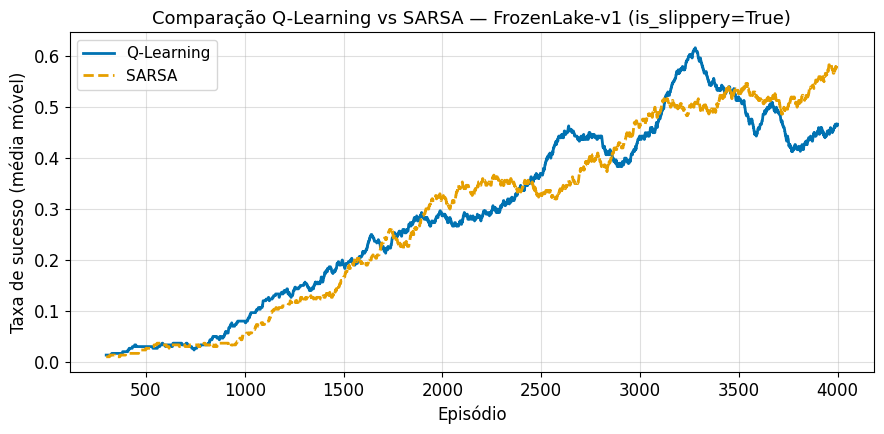

In [5]:
media_movel = rl_utils.media_movel
janela = 300
ma_ql = media_movel(log_ql, janela)
ma_sa = media_movel(log_sa, janela)

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(len(ma_ql)) + janela - 1, ma_ql, label='Q-Learning', linewidth=2)
plt.plot(np.arange(len(ma_sa)) + janela - 1, ma_sa, label='SARSA', linewidth=2, linestyle='--')
plt.title('Comparação Q-Learning vs SARSA — FrozenLake-v1 (is_slippery=True)')
plt.xlabel('Episódio')
plt.ylabel('Taxa de sucesso (média móvel)')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretação da comparação no FrozenLake

No FrozenLake com `is_slippery=True`, o **SARSA tende a superar o Q-Learning** nos episódios finais. Esse resultado pode parecer contraintuitivo — o Q-Learning aprende sobre a política ótima, então por que não teria melhor desempenho?

A resposta está na estocasticidade do ambiente. Com gelo escorregadio, mesmo uma ação gulosa pode levar a um estado indesejado. O SARSA aprende com a política que de fato executa — incluindo ações exploratórias e seus desvios aleatórios — e com isso aprende a ser mais cauteloso perto de buracos.

O Q-Learning, ao usar `max`, aprende como se o futuro fosse determinístico e ótimo. No ambiente escorregadio, essa suposição superestima o valor de certas ações, levando o agente a se posicionar em regiões de maior risco.

**Taxa de sucesso (últimos 500 ep):** ambos estão abaixo do ótimo teórico (~0.74), pois 4.000 episódios é um orçamento limitado para esse ambiente. A diferença entre Q-Learning e SARSA é consistente com a literatura para ambientes escorregadios com penalidades por exploração.

## Comparação visual: mecanismos de atualização

O diagrama abaixo sintetiza o alvo de atualização de cada método em uma única visualização.

In [6]:
metodos = [
    ("Monte Carlo",    "G_t = r + γr' + γ²r'' + ...",    "Retorno completo",     "On-policy"),
    ("TD(0)",          "r + γ·V(s')",                     "Bootstrapping V(s)",   "On-policy"),
    ("Q-Learning",     "r + γ·max Q(s',a')",              "Bootstrapping Q(s,a)", "Off-policy"),
    ("SARSA",          "r + γ·Q(s',a')",                  "Bootstrapping Q(s,a)", "On-policy"),
    ("DQN",            "r + γ·max Q_alvo(s',a')",         "Rede neural + buffer", "Off-policy"),
]

print(f"{'Método':<14} {'Alvo':<32} {'Representação':<22} {'Tipo'}")
print("-" * 80)
for m, alvo, rep, tipo in metodos:
    print(f"{m:<14} {alvo:<32} {rep:<22} {tipo}")

Método         Alvo                             Representação          Tipo
--------------------------------------------------------------------------------
Monte Carlo    G_t = r + γr' + γ²r'' + ...      Retorno completo       On-policy
TD(0)          r + γ·V(s')                      Bootstrapping V(s)     On-policy
Q-Learning     r + γ·max Q(s',a')               Bootstrapping Q(s,a)   Off-policy
SARSA          r + γ·Q(s',a')                   Bootstrapping Q(s,a)   On-policy
DQN            r + γ·max Q_alvo(s',a')          Rede neural + buffer   Off-policy


### Como ler a tabela

A tabela sintetiza as principais dimensões de variação entre os métodos. Três perguntas práticas permitem navegar por ela:

1. **O modelo do ambiente está disponível?** Se sim, Programação Dinâmica calcula valores exatos sem nenhuma interação — é a escolha mais eficiente.

2. **O episódio termina em tempo razoável?** Monte Carlo exige episódios completos. Em episódios longos ou ambientes contínuos, TD e seus derivados funcionam melhor porque atualizam a cada passo.

3. **A exploração tem custo concreto?** Em ambientes onde ações exploratórias geram penalidades — ações ilegais no Taxi, quedas no LunarLander — o SARSA (on-policy) é mais conservador porque internaliza esse custo no alvo. Q-Learning e DQN (off-policy) são mais otimistas e podem aprender políticas mais eficientes, mas ignoram o custo da exploração durante o treinamento.

Os métodos off-policy geralmente convertem experiência em política ótima mais eficientemente. Os métodos on-policy são mais adequados quando o comportamento durante o treinamento precisa ser seguro.

**Leitura reveladora — coluna "Quando atualiza":** apenas o Monte Carlo espera o fim do episódio. Todo método que atualiza a cada passo (TD, Q-Learning, SARSA, DQN) usa bootstrapping — aprende usando estimativas, sem esperar o retorno real. Essa única coluna separa dois mundos: métodos que veem o episódio completo antes de aprender, e métodos que aprendem enquanto o episódio ainda acontece.

## Quando usar cada método

| Situação | Método recomendado |
|---|---|
| Modelo completo disponível, espaço pequeno | Programação Dinâmica |
| Sem modelo, episódios curtos, variância aceitável | Monte Carlo |
| Sem modelo, episódios longos ou contínuos | TD(0) / Q-Learning |
| Exploração custosa, comportamento conservador desejado | SARSA |
| Espaço de estados contínuo, ações discretas | DQN |
| Espaço de ações contínuo | Policy-Based Methods (Aula 03) |

## Bloco 4 — Interpretação pedagógica

A progressão desta aula pode ser resumida por três transições:

**1. Modelo disponível → sem modelo:**  
A DP calcula valores exatos, mas exige o modelo completo. MC e TD aprendem por experiência direta, sem conhecer as transições. A perda do modelo implica usar retornos ruidosos (MC) ou bootstrapping (TD).

**2. Predição → controle:**  
MC e TD(0) estimam V(s) — útil para avaliar uma política. Q-Learning e SARSA estimam Q(s,a) — útil para agir sem um modelo. Q(s,a) encapsula tudo que é necessário para derivar a política ótima.

**3. Tabular → aproximação por função:**  
A tabela Q não escala para estados contínuos. O DQN substitui a tabela por uma rede neural, permitindo generalização entre estados similares. Isso abre o caminho para problemas muito mais ricos, mas introduz instabilidade de treinamento.

## Autoavaliação

<details>
<summary>Pergunta 1: Em qual situação a Programação Dinâmica é o método mais adequado?</summary>

**Resposta:** Quando o modelo completo do ambiente está disponível (probabilidades de transição P(s'|s,a) e recompensas R(s,a)) e o espaço de estados é pequeno e discreto. Exemplos: jogos de tabuleiro com regras explícitas, planejamento em grafos, problemas de otimização combinatória com estrutura de MDP.

**Por quê:** A DP usa o modelo para calcular valores exatos com garantia de convergência. Quando o modelo está disponível, não faz sentido aprender por interação ruidosa — é mais eficiente calcular diretamente.

</details>

<details>
<summary>Pergunta 2: Por que Q-Learning e SARSA não podem ser aplicados diretamente a espaços de ação contínuos?</summary>

**Resposta:** Porque o alvo de atualização usa `max_a Q(s,a)`, que exige enumerar todas as ações possíveis. Em espaços contínuos (como torque de motor ou ângulo de direção), não existe um conjunto finito de ações para iterar. A otimização `max` sobre um espaço contínuo requer uma abordagem diferente — é o que os Policy-Based Methods (Aula 03) resolvem.

**Por quê:** A operação `argmax` sobre ações está implícita em toda política derivada de Q(s,a). Remover essa possibilidade muda fundamentalmente como o agente age.

</details>

<details>
<summary>Pergunta 3: O que torna o SARSA mais conservador que o Q-Learning em ambientes com penalidades exploratórias?</summary>

**Resposta:** O SARSA inclui no alvo de atualização a ação que a política ε-greedy vai de fato executar, inclusive ações aleatórias. Se há chance de executar uma ação penalizada por exploração, o SARSA aprende que esse estado é menos valioso do que parece. O Q-Learning usa `max`, ignorando essa probabilidade — aprende como se o agente sempre agisse de forma ótima.

**Por quê:** On-policy significa aprender sobre o que você realmente faz; off-policy significa aprender sobre o que você poderia fazer idealmente.

</details>

## Mapeamento para o Desafio Final

| Algoritmo | Quando usar no Desafio Final |
|---|---|
| **Programação Dinâmica** | Ambiente com modelo completo e espaço de estados discreto pequeno |
| **Monte Carlo** | Episódios curtos, sem modelo, variância aceitável |
| **TD(0) / Q-Learning** | Aprendizado online sem modelo, episódios longos ou contínuos |
| **SARSA** | Quando o custo de exploração deve ser internalizado (penalidades por ações exploratórias) |
| **DQN** | Estado contínuo ou grande, ações discretas |
| **Policy-based (Aula 03)** | Ações contínuas — torque, velocidade, ângulo |

**Guia de decisão em 3 perguntas:**

1. **Modelo disponível?** Sim → Programação Dinâmica. Não → siga para baixo.
2. **Estado contínuo?** Sim → DQN ou Policy-based. Não → método tabular (MC/TD/Q-Learning/SARSA).
3. **Exploração é custosa ou perigosa?** Sim → SARSA (on-policy). Não → Q-Learning (off-policy).

## Considerações éticas e de fairness

Os métodos desta aula otimizam explicitamente uma função de recompensa. No Notebook 02, vimos um Q-Learning maximizando recompensas no FrozenLake — a mesma lógica que, em aplicações reais, pode maximizar cliques, avaliações ou métricas de engajamento sem considerar impacto social. A questão ética não está no algoritmo, mas no que a recompensa captura.

**Reward hacking em recomendações:** Um agente treinado para maximizar cliques pode aprender a recomendar conteúdo sensacionalista ou polarizante — não porque o desenvolvedor quis, mas porque o sinal de recompensa (clique) é imperfeito. A métrica otimizada não captura o objetivo real (satisfação do usuário, qualidade da informação).

**Viés nos dados de treinamento:** Se o replay buffer ou os episódios de treinamento refletem preferências enviesadas (ex.: dataset histórico coletado de usuários de uma demografia específica), o agente aprende e amplifica esses vieses. Um Q-Learning treinado em dados históricos de um sistema de crédito pode replicar discriminação por raça ou gênero se essas variáveis correlacionam com o retorno.

**Métricas alternativas a considerar:**
- **Cobertura:** quantas categorias/itens distintos o agente recomenda (evita bolhas de filtro)?
- **Diversidade:** o agente cria variedade de exposição para o usuário?
- **Calibração:** as preferências estimadas pelo agente batem com as preferências reais ao longo do tempo?

Ao projetar um sistema de RL para aplicações reais, a definição da função de recompensa é tão crítica quanto a escolha do algoritmo.

## Fio condutor do curso — MovieLens como MDP sequencial (Q-Learning)

Os notebooks anteriores compararam algoritmos em ambientes abstratos (FrozenLake). A célula abaixo fecha o ciclo: aplica Q-Learning tabular ao próprio dataset MovieLens, tratando gêneros como ações e o perfil do usuário como estado.

**MDP simplificado:**
- **Estado (s):** cluster do usuário — 3 perfis baseados na média de avaliações (crítico, mediano, entusiasta)
- **Ação (a):** gênero recomendado — 5 categorias (Action, Comedy, Drama, Romance, Sci-Fi)
- **Recompensa (r):** 1 se `nota ≥ 4`, caso contrário 0

A Q-table aprendida revela qual gênero maximiza o valor esperado de satisfação para cada perfil de usuário.

In [ ]:
import pandas as pd

BASE = os.path.abspath("../..")
GENEROS = ['Action', 'Comedy', 'Drama', 'Romance', 'Sci-Fi']
N_A = len(GENEROS)
N_S = 3
nomes_s = ['Crítico', 'Mediano', 'Entusiasta']

try:
    ratings = pd.read_csv(os.path.join(BASE, "data/movielens/ratings.csv"))
    movies  = pd.read_csv(os.path.join(BASE, "data/movielens/movies.csv"))

    def genero_dom(genres_str):
        for g in GENEROS:
            if g in str(genres_str):
                return GENEROS.index(g)
        return 0

    movies['acao'] = movies['genres'].apply(genero_dom)
    df = ratings.merge(movies[['movieId', 'acao']], on='movieId', how='left').dropna()
    df['gostou'] = (df['rating'] >= 4).astype(float)
    media_u = df.groupby('userId')['rating'].mean()
    df['estado'] = pd.cut(df['userId'].map(media_u), bins=3, labels=[0, 1, 2]).astype(int)
    df_s = df.sample(frac=1, random_state=SEED)
    estados_seq = df_s['estado'].values
    acoes_seq   = df_s['acao'].values.astype(int)
    recomp_seq  = df_s['gostou'].values
    fonte = "dataset MovieLens"

except FileNotFoundError:
    print("Dados MovieLens não encontrados — usando simulação sintética.")
    print("Para usar o dataset real, execute 01_contexto_movielens.ipynb primeiro.\n")
    rng = np.random.default_rng(SEED)
    n = 10_000
    estados_seq = rng.choice(N_S, n, p=[0.25, 0.50, 0.25])
    acoes_seq   = rng.integers(0, N_A, n)
    # Probabilidade base por perfil + leve variação por gênero
    p_base   = np.array([0.33, 0.52, 0.71])
    p_ajuste = np.array([0.04, 0.00, -0.02, 0.02, 0.03])
    recomp_seq = (rng.random(n) < p_base[estados_seq] + p_ajuste[acoes_seq]).astype(float)
    fonte = "simulação sintética"

# Q-Learning tabular (idêntico para dados reais ou sintéticos)
Q_ml = np.zeros((N_S, N_A))
alpha_ml, gamma_ml = 0.05, 0.90
log_rew = []

for s, a, r in zip(estados_seq, acoes_seq, recomp_seq):
    alvo = r + gamma_ml * np.max(Q_ml[s])
    Q_ml[s, a] += alpha_ml * (alvo - Q_ml[s, a])
    log_rew.append(r)

print(f"Q-table aprendida — valor esperado por (perfil, gênero) [{fonte}]:")
header = f"{'Estado':<14}" + "".join(f"{g:<12}" for g in GENEROS) + "→ Recomenda"
print(header)
print("-" * len(header))
for i, nome in enumerate(nomes_s):
    vals = "".join(f"{Q_ml[i, j]:<12.3f}" for j in range(N_A))
    melhor = GENEROS[int(np.argmax(Q_ml[i]))]
    print(f"{nome:<14}{vals}→ {melhor}")
print(f"\nRecompensa média ({fonte}): {np.mean(log_rew):.3f}")

# Visualização da Q-table
P = rl_utils.PALETA_ACESSIVEL
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(Q_ml, cmap='YlOrRd', aspect='auto', vmin=0)
ax.set_xticks(range(N_A)); ax.set_xticklabels(GENEROS)
ax.set_yticks(range(N_S)); ax.set_yticklabels(nomes_s)
plt.colorbar(im, ax=ax, label='Q(estado, gênero)')
for i in range(N_S):
    for j in range(N_A):
        ax.text(j, i, f"{Q_ml[i, j]:.2f}", ha='center', va='center', fontsize=9,
                color='white' if Q_ml[i, j] > Q_ml.max() * 0.6 else 'black')
ax.set_title(f'Q-Learning no MovieLens — valor esperado de cada gênero por perfil\n({fonte})')
plt.tight_layout()
plt.show()

## Bloco 5 — Limites dos métodos value-based e transição para a Aula 03

Os métodos desta aula têm um ponto cego em comum: **assumem que as ações são discretas e enumeráveis**. A operação `max_a Q(s,a)` exige poder comparar o valor de cada ação possível.

Em robótica, controle contínuo e muitos problemas do mundo real, as ações são contínuas. Não é possível enumerar todos os torques possíveis de um motor ou todos os ângulos de direção de um veículo.

**Por que não simplesmente discretizar as ações contínuas?**

Parece natural dividir cada dimensão contínua em bins. Mas a maldição da dimensionalidade torna isso impraticável: um robô com 7 juntas, com apenas 10 bins por junta, gera 10⁷ = 10 milhões de ações possíveis. Para ter uma referência concreta: o Taxi-v3 — o ambiente tabular desta aula — avalia **6 ações por estado**. Com 10 bins por junta, o robô avalia **10 milhões de ações por estado**, ou seja, 1,6 milhão de vezes mais. A operação `max_a Q(s,a)` precisaria percorrer todas elas a cada passo. Com 100 bins por junta, seriam 10¹⁴ ações — completamente intratável, mesmo em hardware moderno. Além disso, movimentos discretizados seriam mecânicos e ineficientes: um motor nunca aplica exatamente um dos 10 torques predefinidos em cada situação.

Os *Policy-Based Methods* (Aula 03) contornam esse problema emitindo a ação **diretamente como saída da rede**, sem enumeração.

A **Aula 03** responde a esse desafio com uma abordagem diferente: em vez de aprender uma função de valor e derivar a política indiretamente, aprender **a política diretamente** — otimizando os parâmetros da política por gradiente. Essa família inclui REINFORCE, Actor-Critic e PPO.

> **Ponto de partida da Aula 03:** *Se policy-based methods otimizam a política diretamente, como calculamos o gradiente da política?*

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| value-based methods | métodos baseados em valor | Família de algoritmos que aprende Q(s,a) ou V(s) para derivar a política. |
| tabular method | método tabular | Algoritmo que armazena um valor explícito por estado (ou par estado-ação). |
| deadly triad | tríade mortal | Instabilidade causada pela combinação bootstrapping + off-policy + aproximação por função. |
| policy-based methods | métodos baseados em política | Família que otimiza diretamente os parâmetros da política (REINFORCE, PPO — tema da Aula 03). |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Cap. 13 (Policy Gradient Methods). Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.
- OpenAI Spinning Up. *Introduction to RL: Key Concepts and Terminology*. Disponível em: https://spinningup.openai.com/en/latest/spinningup/rl_intro.html. Acesso em: abril 2026.
- Farama Foundation. *Gymnasium documentation*. Disponível em: https://gymnasium.farama.org. Acesso em: abril 2026.